In [13]:
import os,sys,glob
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, LogNorm
from matplotlib.ticker import LogFormatter, LogLocator, LogFormatterExponent # <-- one new import here
from matplotlib.collections import LineCollection

import funcs as funcs
import params
import scipy.io as sio
from datetime import date
import pandas as pd
import geopandas as gpd
from netCDF4 import Dataset
import xarray as xr
from pycpt.load import gmtColormap

import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shutup 
shutup.please()
import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/pvn/research/STUDY/Projects/DOE/SETx-UIFL/TC_Downscaling/')
import notebooks.funcs as funcplots

In [28]:
# Mapping boundary and projection
xmin = -110; xmax = 0; ymin = 0; ymax = 60
proj = ccrs.AzimuthalEquidistant(central_longitude=-50,central_latitude=30)
fontfamily = 'Arial'

# Colormaps
newcolors = plt.cm.turbo(np.linspace(0, 1, 256))
white = np.array([256/256, 256/256, 256/256, 1])
newcolors[:int(0.02*256), :] = white
cmap = ListedColormap(newcolors)
cmap_den = cmap
cmap_trk = plt.cm.turbo
cmap_pr = gmtColormap('/Users/pvn/research/STUDY/Projects/DOE/SETx-UIFL/TC_Downscaling/colormaps/precip2_17lev.cpt')

# Parameters
cell_size = 2       # Size of lat-lon box for counting tracks on map.
wind_thres = 27     # 27 m/s or 100 km/h

# Shapefile
fnCONUS = '/Users/pvn/Library/CloudStorage/OneDrive-OakRidgeNationalLaboratory/STUDY/Documents/Proposals/DOE/DOE-CAREER-2023/Data/notebooks/BestTracks/CONUS/CONUS.shp'
shpCONUS = shpreader.Reader(fnCONUS)

# Plotting period
yearmin = 1964
yearmax = 2014
num_year = yearmax - yearmin + 1

In [3]:
pathdir = '/Users/pvn/research/STUDY/Projects/DOE/SETx-UIFL/TC_Downscaling/Downscaled_10k/'
model = 'E3SM-1-0'
expmnt = 'historical'

In [4]:
filename = glob.glob('%s/%s/tracks_NA_%s_%s_*.nc' % (pathdir,expmnt,model,expmnt))[0]
ds = xr.open_dataset(filename)
lat_trks = ds['lat_trks'].values
lon_trks = ds['lon_trks'].values

n_trk = ds['n_trk'].values
v_trks = ds['v_trks'].values
vmax_trks = ds['vmax_trks'].values
u850_trks = ds['u850_trks'].values
v850_trks = ds['v850_trks'].values
tc_month = ds['tc_month'].values
tc_years = ds['tc_years'].values
tc_time = ds['time'].values

In [5]:
if 'rm_trks' not in list(ds.keys()):
    ro = 1000.          # Outer radius
    wc = 3.0            # Radiative subsidence rate
    cdouter = 1.2e-3    # Drag coefficient
    nouter = 1000       # Number of radial point
    num_tcs = len(n_trk)
    len_tcs = len(tc_time)

    rm_trks = np.nan * np.zeros(vmax_trks.shape)
    for ind in range(num_tcs):
        vmax = vmax_trks[ind,:]
        vmax = vmax[~np.isnan(vmax)]
        jmax = len(vmax)
        for jnd in range(jmax):
            alats = lat_trks[ind,jnd]
            vsin = vmax_trks[ind,jnd]
            fc1 = 1.45e-4 * np.abs(alats * 0.0175)
            vouter, rm, imin = funcs.vouternew(vsin,fc1,ro,wc,cdouter,nouter)
            rm_trks[ind,jnd] = rm                
        if ind % 100 == 0:
            print(ind)
    ds = ds.assign(rm_trks=(['n_trk','time'],rm_trks))
    
    if os.path.exists(filename):
        os.remove(filename)
    ds.to_netcdf(filename, mode = 'w')
else:    
    print('Radius of maximum was already estimated!!!')
    print('Loading rm_trks..........')
    rm_trks = ds['rm_trks'].values

Radius of maximum was already estimated!!!
Loading rm_trks..........


In [19]:
gpdCONUS = gpd.read_file(fnCONUS)
gpdTX = gpdCONUS[gpdCONUS['NAME']=='Texas']
polygon = gpdTX.geometry
number_trks = 1020
ind_hist_TX = funcplots.GetTracksLandfallPolygon(lat_trks, lon_trks, number_trks, polygon)

In [43]:
# ind_hist_TX

In [8]:
ut, vt, jmax = funcs.utrans(lat_trks, lon_trks)

In [44]:
nt = 524
x,y,netrain = funcs.rainswathx(nt, lat_trks, lon_trks, rm_trks, v_trks, 0*rm_trks, 0*v_trks, ut, vt, u850_trks, v850_trks)

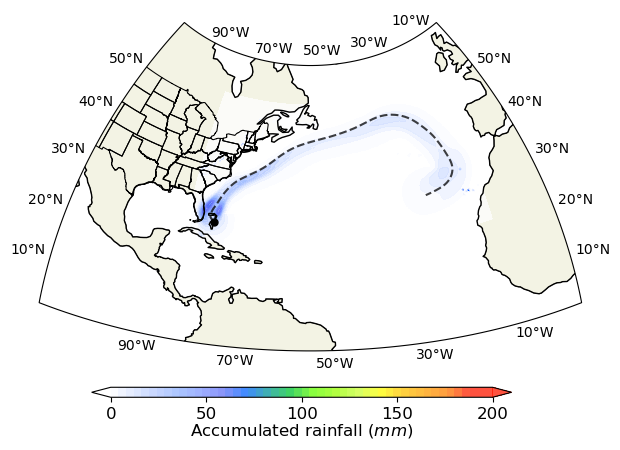

In [45]:
alpha = 0.75
cmap_pr = gmtColormap('/Users/pvn/research/STUDY/Projects/DOE/SETx-UIFL/TC_Downscaling/colormaps/precip3_16lev.cpt')
proj = ccrs.AzimuthalEquidistant(central_longitude=-55,central_latitude=30)
fig, ax = plt.subplots(1,1, figsize=(7,5), facecolor="w", subplot_kw=dict(projection=proj))

############ PLOT Net Rainfall 
max_precip = 200
levels = np.linspace(0,max_precip,51)
im = funcplots.Plot_Density(ax, y, x, netrain, xmin, xmax, ymin, ymax, 
                        alpha, cmap_pr, levels, fontfamily, logscale=False, xlabel=False, ylabel=False, shp=shpCONUS, 
                        title=None, tsize=14, tcolor='k', tstyle='bold')

ax.plot(lon_trks[nt,:],lat_trks[nt,:],color='k',ls='--',alpha=0.75,transform=ccrs.PlateCarree(),zorder=1)
ax.plot(lon_trks[nt,0],lat_trks[nt,0],'ok',ms=5,alpha=1,transform=ccrs.PlateCarree(),zorder=1)

gl = ax.gridlines(draw_labels=True, xlocs=np.arange(-90,1,20), ylocs=np.arange(10,61,10), 
                rotate_labels=False, x_inline=False, y_inline=False, lw=0.0) 

cbax = fig.add_axes([0.2,0.06,0.6,0.02])
cb = fig.colorbar(im, cax=cbax, orientation='horizontal')
cb.set_label(r'Accumulated rainfall ($mm$)', fontsize=12, labelpad=0)
cb.set_ticks(np.linspace(0,max_precip,5))
cb.ax.tick_params(labelsize=12)

# plt.savefig('/Users/pvn/Downloads/TCR_map1.png',
#             bbox_inches ="tight", dpi=600,
#             transparent = True)